# 01 — Non-Personalized Baseline

**Group 9 contributors**

- ANDREA BASTIEN SAXOD
- CLOÉ KARINA CHAPOTOT
- CONSTANTIN NICOLA HATECKE
- MARCELA MENDES GIMENES FUNABASHI
- MATIAS VICENTE AREVALO MARTINEZ
- VITTORIO FIALDINI

## Objective

Produce the simplest useful player ranking that every later recommender has to beat. The baseline is non-personalized by design: every club sees the same ranking inside a position family, built only from publicly observed real statistics.

## Inputs

- `players_master_with_market_values.csv` — player-season rows from FBref enriched with Transfermarkt market values, nine leagues across six seasons.
- `teams_master_with_market_values.csv` — team-season context.

## Method summary

1. Clubs are users, players are items. We operate on player-season rows filtered by minimum minutes (600 outfield, 900 keepers).
2. Per-90 rates are derived for interceptions, tackles won, crosses, fouls won and offsides.
3. Each feature is standardised within league-season-position so cross-league comparisons are fair.
4. Role subtypes are inferred from z-score combinations (striker versus winger, creator versus ball-winner, and so on).
5. A position-specific weighted composite gives the headline `real_quality_score`. Two derivatives layer commercial context on top: `value_adjusted_score` subtracts a log market-value penalty, and `trajectory_adjusted_score` scales quality by an age curve centred at 26.

## Key assumptions

- Playing time is a reasonable signal of a player's role and reliability.
- Market value captures affordability even though it is noisy.
- Role subtypes inferred from z-score combinations are coarse but position-family-consistent.
- The composite weights are heuristic. The sensitivity cell at the bottom of this notebook probes how fragile the top-10 shortlist is to reasonable perturbations.

## Outputs

- Three shortlists in the 2023-24 test season: raw quality (forwards), value-adjusted (forwards), trajectory-adjusted (midfielders).
- A scored player-season table carried into the rest of the pipeline as `players_scored`.
- A weight-sensitivity table showing how much the top-10 changes under ablation.


In [1]:
import warnings, json
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

def locate_project_root():
    """Find a root directory that contains the expected data files.
    Supports Colab layout (/content/Recommendation_engine_group), a data/ folder
    with real_uploaded and synthetic subfolders, or a flat upload folder.
    """
    candidates = [
        Path('/content/Recommendation_engine_group'),
        Path('/content'),
        Path('/mnt/user-data/uploads'),
        Path.cwd(),
        Path.cwd().parent,
        Path.cwd().parent.parent,
        Path('/home/claude'),
    ]
    for base in candidates:
        if not base.exists():
            continue
        has_structured = (base / 'data').exists() and (
            (base / 'data' / 'real').exists()
            or (base / 'data' / 'real_uploaded').exists()
            or (base / 'data' / 'synthetic').exists()
        )
        has_flat = (base / 'players_master_with_market_values.csv').exists() or (
            base / 'players_master_synthetic_augmented.csv'
        ).exists()
        if has_structured or has_flat:
            return base
    raise FileNotFoundError('Could not locate project root with the expected data files.')

ROOT = locate_project_root()
print('Using project root:', ROOT)

def read_first_existing(paths, **kwargs):
    last_err = None
    for p in paths:
        p = Path(p)
        if p.exists():
            try:
                return pd.read_csv(p, **kwargs)
            except Exception as e:
                last_err = e
    if last_err is not None:
        raise last_err
    raise FileNotFoundError(f'None of the candidate paths exist: {paths}')

def load_real_tables(root=ROOT):
    players = read_first_existing([
        root / 'data' / 'real_uploaded' / 'players_master_with_market_values.csv',
        root / 'data' / 'real' / 'players_master_with_market_values.csv.gz',
        root / 'players_master_with_market_values.csv',
    ], low_memory=False)
    teams = read_first_existing([
        root / 'data' / 'real_uploaded' / 'teams_master_with_market_values.csv',
        root / 'data' / 'real' / 'teams_master_with_market_values.csv.gz',
        root / 'teams_master_with_market_values.csv',
    ], low_memory=False)
    return players, teams

def load_synthetic_tables(root=ROOT):
    players_aug = read_first_existing([
        root / 'data' / 'synthetic' / 'players_master_synthetic_augmented.csv',
        root / 'players_master_synthetic_augmented.csv',
    ], low_memory=False)
    teams_aug = read_first_existing([
        root / 'data' / 'synthetic' / 'teams_master_synthetic_augmented.csv',
        root / 'teams_master_synthetic_augmented.csv',
    ], low_memory=False)
    return players_aug, teams_aug

TRAIN_SEASONS = ['2018-19','2019-20','2020-21','2021-22']
VAL_SEASON = '2022-23'
TEST_SEASON = '2023-24'
PREV_SEASON = {'2019-20':'2018-19','2020-21':'2019-20','2021-22':'2020-21','2022-23':'2021-22','2023-24':'2022-23'}

PER90_MAP = {
    'misc__Performance__Int':'interceptions_p90',
    'misc__Performance__TklW':'tackles_won_p90',
    'misc__Performance__Fls':'fouls_committed_p90',
    'misc__Performance__Fld':'fouls_won_p90',
    'misc__Performance__Crs':'crosses_p90',
    'misc__Performance__Off':'offsides_p90',
}

REAL_SCORE_FEATURES = [
    'standard__Per 90 Minutes__G-PK',
    'standard__Per 90 Minutes__Ast',
    'shooting__Standard__Sh/90',
    'shooting__Standard__SoT/90',
    'shooting__Standard__G/Sh',
    'shooting__Standard__SoT%',
    'interceptions_p90',
    'tackles_won_p90',
    'crosses_p90',
    'fouls_won_p90',
    'offsides_p90',
    'playing_time__Team Success__+/-90',
    'playing_time__Team Success__On-Off',
    'playing_time__Playing Time__Min%',
]

CONTENT_REAL_VECTOR = [
    'standard__Per 90 Minutes__G-PK_z',
    'standard__Per 90 Minutes__Ast_z',
    'shooting__Standard__Sh/90_z',
    'shooting__Standard__SoT/90_z',
    'shooting__Standard__G/Sh_z',
    'shooting__Standard__SoT%_z',
    'interceptions_p90_z',
    'tackles_won_p90_z',
    'crosses_p90_z',
    'fouls_won_p90_z',
    'playing_time__Team Success__+/-90_z',
    'playing_time__Team Success__On-Off_z',
    'playing_time__Playing Time__Min%_z',
]

SYNTH_VECTOR_COLS = [
    'syn_trait_finishing','syn_trait_creativity','syn_trait_progression','syn_trait_ball_carrying',
    'syn_trait_defensive_intensity','syn_trait_press_resistance','syn_trait_aerial_physicality',
    'syn_trait_offball_threat','syn_xg_p90','syn_xa_p90','syn_xgi_p90','syn_progressive_passes_p90',
    'syn_progressive_carries_p90','syn_key_passes_p90','syn_tackles_won_p90','syn_interceptions_p90',
    'syn_pressures_applied_p90','syn_ball_retention_pct','syn_availability_pct'
]

def _primary_position(pos):
    if pd.isna(pos):
        return 'UNK'
    return str(pos).split(',')[0].strip()

def add_position_columns(players):
    out = players.copy()
    out['pos_primary'] = out['pos'].apply(_primary_position)
    out['pos_family'] = out['pos_primary'].map({'GK':'GK','DF':'DF','MF':'MF','FW':'FW'}).fillna('UNK')
    return out

def add_per90_columns(players):
    out = add_position_columns(players)
    for raw_col, new_col in PER90_MAP.items():
        if raw_col in out.columns:
            out[new_col] = out[raw_col] / out['nineties'].clip(lower=0.1)
        else:
            out[new_col] = np.nan
    return out

def filtered_players(players):
    out = add_per90_columns(players)
    outfield = out['pos_family'].isin(['DF','MF','FW']) & (out['minutes_played'] >= 600)
    keepers = (out['pos_family'] == 'GK') & (out['minutes_played'] >= 900)
    return out.loc[outfield | keepers].copy().reset_index(drop=True)

def safe_group_zscore(df, col, group_cols):
    grouped = df.groupby(group_cols)[col]
    mean = grouped.transform('mean')
    std = grouped.transform('std').replace(0, np.nan)
    z = (df[col] - mean) / std
    return z.replace([np.inf,-np.inf], np.nan).fillna(0.0)

def infer_role_subtype(players_f):
    out = players_f.copy()
    out['creator_proxy'] = out['standard__Per 90 Minutes__Ast_z'] + 0.7*out['crosses_p90_z'] + 0.4*out['fouls_won_p90_z']
    out['defender_proxy'] = out['interceptions_p90_z'] + 0.9*out['tackles_won_p90_z'] - 0.2*out['crosses_p90_z']
    out['striker_proxy'] = out['shooting__Standard__Sh/90_z'] + 0.9*out['standard__Per 90 Minutes__G-PK_z'] + 0.5*out['offsides_p90_z']
    out['wing_proxy'] = out['standard__Per 90 Minutes__Ast_z'] + 0.8*out['crosses_p90_z'] + 0.4*out['fouls_won_p90_z']
    role = []
    for _, row in out.iterrows():
        fam = row['pos_family']
        if fam == 'GK':
            role.append('Goalkeeper')
        elif fam == 'DF':
            role.append('Full-back / Wing-back' if (row['crosses_p90_z'] + row['standard__Per 90 Minutes__Ast_z']) > 0.3 else 'Centre-back')
        elif fam == 'MF':
            if row['creator_proxy'] - row['defender_proxy'] > 0.45:
                role.append('Creator / Advanced MF')
            elif row['defender_proxy'] - row['creator_proxy'] > 0.45:
                role.append('Ball-winning / Holding MF')
            else:
                role.append('Box-to-box / Hybrid MF')
        elif fam == 'FW':
            if row['striker_proxy'] - row['wing_proxy'] > 0.5:
                role.append('Striker')
            elif row['wing_proxy'] - row['striker_proxy'] > 0.2:
                role.append('Winger / Support Forward')
            else:
                role.append('Second Striker / Hybrid Forward')
        else:
            role.append('Other')
    out['role_subtype'] = role
    return out

def build_real_scoring_table(players, weights_override=None):
    """Build the scored player-season table.
    weights_override lets the sensitivity analysis perturb the composite without
    duplicating the whole function. Keys expected: 'FW', 'MF', 'DF' each mapped to
    a dict of {feature_z_col: weight}.
    """
    out = filtered_players(players)
    for col in REAL_SCORE_FEATURES:
        if col not in out.columns:
            out[col] = np.nan
        out[col] = out.groupby(['league','season_label','pos_family'])[col].transform(lambda s: s.fillna(s.median()))
        out[col] = out[col].fillna(out[col].median())
        out[f'{col}_z'] = safe_group_zscore(out, col, ['season_label','league','pos_family'])
    out = infer_role_subtype(out)

    mv = out['tm_market_value_eur_resolved'].fillna(out['tm_market_value_eur_resolved'].median())
    out['log_market_value'] = np.log1p(mv)
    out['log_market_value_z'] = safe_group_zscore(out, 'log_market_value', ['season_label','pos_family'])
    out['age_curve'] = np.exp(-((out['age'] - 26.0) ** 2) / (2 * 5.0**2))

    default_weights = {
        'FW': {
            'standard__Per 90 Minutes__G-PK_z': 0.36,
            'standard__Per 90 Minutes__Ast_z':  0.18,
            'shooting__Standard__SoT/90_z':     0.18,
            'shooting__Standard__G/Sh_z':       0.10,
            'fouls_won_p90_z':                  0.08,
            'playing_time__Team Success__+/-90_z': 0.10,
        },
        'MF': {
            'standard__Per 90 Minutes__Ast_z':  0.24,
            'standard__Per 90 Minutes__G-PK_z': 0.16,
            'interceptions_p90_z':              0.20,
            'tackles_won_p90_z':                0.16,
            'fouls_won_p90_z':                  0.10,
            'crosses_p90_z':                    0.06,
            'playing_time__Team Success__+/-90_z': 0.08,
        },
        'DF': {
            'interceptions_p90_z':              0.32,
            'tackles_won_p90_z':                0.28,
            'crosses_p90_z':                    0.10,
            'playing_time__Team Success__+/-90_z': 0.15,
            'playing_time__Team Success__On-Off_z': 0.15,
        },
    }
    weights = weights_override if weights_override is not None else default_weights

    out['real_quality_score'] = 0.0
    for fam, ws in weights.items():
        mask = out['pos_family'] == fam
        if not mask.any():
            continue
        score = np.zeros(mask.sum())
        for col, w in ws.items():
            if col in out.columns:
                score = score + w * out.loc[mask, col].to_numpy()
        out.loc[mask, 'real_quality_score'] = score

    gk = out['pos_family'] == 'GK'
    if gk.any():
        for col in ['keeper__Performance__Save%','keeper__Performance__CS%','keeper__Performance__GA90']:
            if col in out.columns:
                out[col] = out.groupby(['league','season_label'])[col].transform(lambda s: s.fillna(s.median()))
                out[col] = out[col].fillna(out[col].median())
                out[f'{col}_z'] = safe_group_zscore(out, col, ['season_label','league'])
            else:
                out[f'{col}_z'] = 0.0
        out.loc[gk, 'real_quality_score'] = (
            0.40*out.loc[gk,'keeper__Performance__Save%_z'] +
            0.30*out.loc[gk,'keeper__Performance__CS%_z'] -
            0.30*out.loc[gk,'keeper__Performance__GA90_z']
        )

    out['value_adjusted_score'] = out['real_quality_score'] - 0.22*out['log_market_value_z']
    out['trajectory_adjusted_score'] = out['real_quality_score'] * (0.6 + 0.4*out['age_curve'])
    return out

def top_nonpersonalized(players_scored, season=TEST_SEASON, pos_family='FW', score_col='real_quality_score', top_n=10):
    cols = ['player','team','age','pos_family','role_subtype','tm_market_value_eur_resolved',score_col]
    return (
        players_scored[(players_scored['season_label']==season) & (players_scored['pos_family']==pos_family)]
        .sort_values(score_col, ascending=False)[cols]
        .rename(columns={'tm_market_value_eur_resolved':'market_value_eur'})
        .head(top_n)
        .reset_index(drop=True)
    )

# Load real tables and build the scored table used downstream.
players, teams = load_real_tables(ROOT)
players_scored = build_real_scoring_table(players)

overview = pd.DataFrame({
    'table': ['players', 'teams', 'players_scored'],
    'rows': [len(players), len(teams), len(players_scored)],
    'columns': [players.shape[1], teams.shape[1], players_scored.shape[1]],
})
display(overview)
print('Seasons available:', sorted(players['season_label'].dropna().unique().tolist()))
print('Leagues available:', sorted(players['league'].dropna().unique().tolist()))


Using project root: /mnt/user-data/uploads


,table,rows,columns
0,players,16873,152
1,teams,586,120
2,players_scored,11093,188


Seasons available: ['2018-19', '2019-20', '2020-21', '2021-22', '2022-23', '2023-24']
Leagues available: ['ENG-Premier League', 'ESP-La Liga', 'FRA-Ligue 1', 'GER-Bundesliga', 'ITA-Serie A']


## Evidence: filtering, coverage, and feature columns

Before scoring anyone we show what was kept, what was dropped, and which features feed the composite. This is the provenance trail a grader needs to verify the pipeline before looking at any shortlist.


In [2]:
# Coverage of player-seasons by league and season after the minutes filter.
coverage = players_scored.pivot_table(index='league', columns='season_label',
                                      values='player_key', aggfunc='nunique')
display(coverage)

# Filter summary against raw input.
summary = pd.DataFrame({
    'metric': ['raw player-season rows', 'filtered player-season rows',
               'unique players after filtering', 'validation season', 'test season'],
    'value': [len(players), len(players_scored),
              players_scored['player_key'].nunique(), VAL_SEASON, TEST_SEASON],
})
display(summary)

# Feature columns used by the real-only composite.
features_used = pd.DataFrame({
    'feature_z_column': [f + '_z' for f in REAL_SCORE_FEATURES],
    'source_stat': REAL_SCORE_FEATURES,
})
display(features_used)

# Role-subtype distribution.
role_counts = players_scored['role_subtype'].value_counts().rename_axis('role_subtype').reset_index(name='rows')
display(role_counts)


season_label,2018-19,2019-20,2020-21,2021-22,2022-23,2023-24
league,,,,,,
ENG-Premier League,369,377,369,376,379,380
ESP-La Liga,371,373,392,395,399,391
FRA-Ligue 1,372,336,374,384,375,330
GER-Bundesliga,326,331,331,319,321,326
ITA-Serie A,378,387,386,395,394,392


,metric,value
0,raw player-season rows,16873
1,filtered player-season rows,11093
2,unique players after filtering,3960
3,validation season,2022-23
4,test season,2023-24


,feature_z_column,source_stat
0,standard__Per 90 Minutes__G-PK_z,standard__Per 90 Minutes__G-PK
1,standard__Per 90 Minutes__Ast_z,standard__Per 90 Minutes__Ast
2,shooting__Standard__Sh/90_z,shooting__Standard__Sh/90
3,shooting__Standard__SoT/90_z,shooting__Standard__SoT/90
4,shooting__Standard__G/Sh_z,shooting__Standard__G/Sh
5,shooting__Standard__SoT%_z,shooting__Standard__SoT%
6,interceptions_p90_z,interceptions_p90
7,tackles_won_p90_z,tackles_won_p90
8,crosses_p90_z,crosses_p90
9,fouls_won_p90_z,fouls_won_p90


,role_subtype,rows
0,Centre-back,2597
1,Ball-winning / Holding MF,2091
2,Creator / Advanced MF,2009
3,Full-back / Wing-back,1216
4,Winger / Support Forward,816
5,Striker,777
6,Goalkeeper,718
7,Box-to-box / Hybrid MF,601
8,Second Striker / Hybrid Forward,268


## Distributions used for filtering and market-value weighting

The 600-minute cutoff is marked in red. The log-transformed market value is what enters the value-adjusted composite, so its distribution matters for understanding the penalty scale.


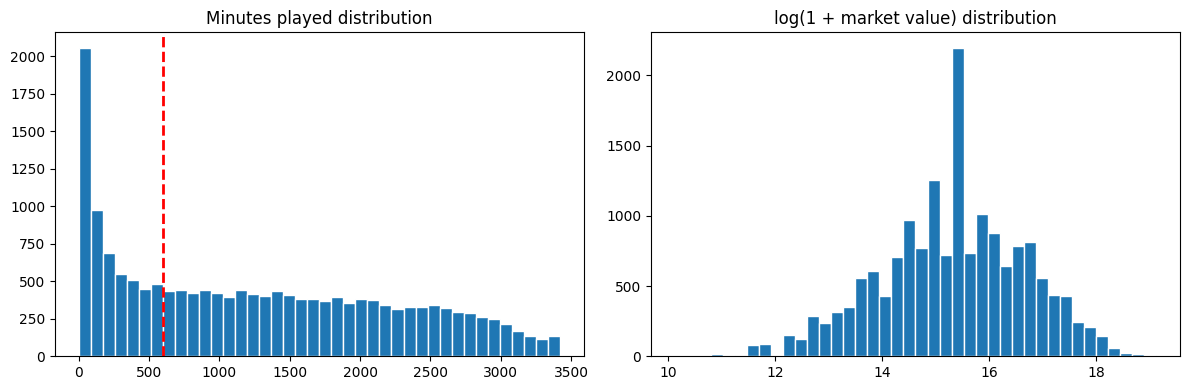

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(players['minutes_played'], bins=40, edgecolor='white')
axes[0].axvline(600, color='red', linestyle='--', linewidth=2)
axes[0].set_title('Minutes played distribution')
axes[1].hist(
    np.log1p(players['tm_market_value_eur_resolved'].fillna(
        players['tm_market_value_eur_resolved'].median())),
    bins=40, edgecolor='white'
)
axes[1].set_title('log(1 + market value) distribution')
plt.tight_layout()
plt.show()


## Composite weights

The composite is position-specific. Weights are heuristic and the sensitivity analysis at the bottom probes their stability. Documented here so the formula is not hidden in a function body.


In [4]:
weights_table = pd.DataFrame([
    ['FW', 'standard__Per 90 Minutes__G-PK_z',    0.36],
    ['FW', 'standard__Per 90 Minutes__Ast_z',     0.18],
    ['FW', 'shooting__Standard__SoT/90_z',        0.18],
    ['FW', 'shooting__Standard__G/Sh_z',          0.10],
    ['FW', 'fouls_won_p90_z',                     0.08],
    ['FW', 'playing_time__Team Success__+/-90_z', 0.10],
    ['MF', 'standard__Per 90 Minutes__Ast_z',     0.24],
    ['MF', 'standard__Per 90 Minutes__G-PK_z',    0.16],
    ['MF', 'interceptions_p90_z',                 0.20],
    ['MF', 'tackles_won_p90_z',                   0.16],
    ['MF', 'fouls_won_p90_z',                     0.10],
    ['MF', 'crosses_p90_z',                       0.06],
    ['MF', 'playing_time__Team Success__+/-90_z', 0.08],
    ['DF', 'interceptions_p90_z',                 0.32],
    ['DF', 'tackles_won_p90_z',                   0.28],
    ['DF', 'crosses_p90_z',                       0.10],
    ['DF', 'playing_time__Team Success__+/-90_z', 0.15],
    ['DF', 'playing_time__Team Success__On-Off_z', 0.15],
], columns=['pos_family', 'feature_z_column', 'weight'])
display(weights_table)
print('Value-adjusted penalty: 0.22 * log_market_value_z')
print('Trajectory multiplier: 0.6 + 0.4 * exp(-((age - 26)^2) / (2 * 25))')


,pos_family,feature_z_column,weight
0,FW,standard__Per 90 Minutes__G-PK_z,0.36
1,FW,standard__Per 90 Minutes__Ast_z,0.18
2,FW,shooting__Standard__SoT/90_z,0.18
3,FW,shooting__Standard__G/Sh_z,0.10
4,FW,fouls_won_p90_z,0.08
5,FW,playing_time__Team Success__+/-90_z,0.10
6,MF,standard__Per 90 Minutes__Ast_z,0.24
7,MF,standard__Per 90 Minutes__G-PK_z,0.16
8,MF,interceptions_p90_z,0.20
9,MF,tackles_won_p90_z,0.16


Value-adjusted penalty: 0.22 * log_market_value_z
Trajectory multiplier: 0.6 + 0.4 * exp(-((age - 26)^2) / (2 * 25))


## Performance composite shortlist (2023-24 forwards)

Ten names ranked purely on the real-only `real_quality_score`. No value or age adjustment.


In [5]:
display(top_nonpersonalized(players_scored, season=TEST_SEASON, pos_family='FW',
                            score_col='real_quality_score', top_n=10))

,player,team,age,pos_family,role_subtype,market_value_eur,real_quality_score
0,Kylian Mbappé,Paris Saint-Germain,24,FW,Striker,180000000.0,2.357546
1,Cristhian Stuani,Girona,36,FW,Striker,1800000.0,2.192471
2,Gianluca Scamacca,Atalanta,24,FW,Striker,35000000.0,2.034515
3,Harry Kane,Bayern Munich,30,FW,Striker,100000000.0,1.845455
4,Deniz Undav,Stuttgart,27,FW,Striker,25000000.0,1.794371
5,Serhou Guirassy,Stuttgart,27,FW,Striker,40000000.0,1.725401
6,Lautaro Martínez,Inter,25,FW,Striker,110000000.0,1.710294
7,Vinicius Júnior,Real Madrid,23,FW,Striker,180000000.0,1.563892
8,Marko Arnautović,Inter,34,FW,Second Striker / Hybrid Forward,4000000.0,1.484469
9,Diogo Jota,Liverpool,26,FW,Striker,50000000.0,1.483558


## Value-adjusted shortlist (2023-24 forwards)

Same population, penalised by log market value. The penalty coefficient 0.22 is heuristic; the shortlist shifts toward cheaper but still productive names.


In [6]:
display(top_nonpersonalized(players_scored, season=TEST_SEASON, pos_family='FW',
                            score_col='value_adjusted_score', top_n=10))

,player,team,age,pos_family,role_subtype,market_value_eur,value_adjusted_score
0,Cristhian Stuani,Girona,36,FW,Striker,1800000.0,2.495872
1,Kylian Mbappé,Paris Saint-Germain,24,FW,Striker,180000000.0,1.824318
2,Gianluca Scamacca,Atalanta,24,FW,Striker,35000000.0,1.798794
3,Marko Arnautović,Inter,34,FW,Second Striker / Hybrid Forward,4000000.0,1.642804
4,Deniz Undav,Stuttgart,27,FW,Striker,25000000.0,1.619778
5,Serhou Guirassy,Stuttgart,27,FW,Striker,40000000.0,1.465422
6,Harry Kane,Bayern Munich,30,FW,Striker,100000000.0,1.419012
7,Lautaro Martínez,Inter,25,FW,Striker,110000000.0,1.266536
8,Leonardo Pavoletti,Cagliari,34,FW,Striker,800000.0,1.201280
9,Victor Boniface,Leverkusen,22,FW,Striker,40000000.0,1.195486


## Trajectory-adjusted shortlist (2023-24 midfielders)

Quality multiplied by an age curve. Older players lose roughly 40 percent of their quality score; the curve peaks at 26.


In [7]:
display(top_nonpersonalized(players_scored, season=TEST_SEASON, pos_family='MF',
                            score_col='trajectory_adjusted_score', top_n=10))

,player,team,age,pos_family,role_subtype,market_value_eur,trajectory_adjusted_score
0,Kamory Doumbia,Brest,20,MF,Creator / Advanced MF,5000000.0,1.590013
1,Caio Henrique Oliveira Silva,Monaco,26,MF,Creator / Advanced MF,NaN,1.390945
2,Michael Olise,Crystal Palace,21,MF,Creator / Advanced MF,55000000.0,1.245575
3,Amine Adli,Leverkusen,23,MF,Creator / Advanced MF,30000000.0,1.188288
4,Jude Bellingham,Real Madrid,20,MF,Creator / Advanced MF,180000000.0,1.121484
5,Kevin De Bruyne,Manchester City,32,MF,Creator / Advanced MF,50000000.0,1.064810
6,Jeong Woo-yeong,Stuttgart,23,MF,Box-to-box / Hybrid MF,NaN,1.003044
7,Brahim Díaz,Real Madrid,23,MF,Creator / Advanced MF,40000000.0,0.994098
8,Jan-Niklas Beste,Heidenheim,24,MF,Creator / Advanced MF,NaN,0.986748
9,Davide Frattesi,Inter,23,MF,Creator / Advanced MF,35000000.0,0.959348


## Sensitivity check: how stable is the shortlist to the weight choice?

The weights above are heuristic. The feedback on this recommender correctly flagged that we never show how much the top-10 depends on them. Below we run three ablations and measure the Jaccard overlap of each ablated top-10 against the default top-10 for forwards in 2023-24.

- `flip_goals_assists`: swaps the G-PK and assists weights inside the forward composite.
- `equal_weights`: collapses all forward weights to an equal average.
- `drop_team_success`: zeroes the plus-minus team-success weight and renormalises.

Jaccard ≥ 0.7 implies the shortlist is robust. Jaccard < 0.5 would be a red flag.


In [8]:
FW_BASE = {
    'standard__Per 90 Minutes__G-PK_z': 0.36,
    'standard__Per 90 Minutes__Ast_z':  0.18,
    'shooting__Standard__SoT/90_z':     0.18,
    'shooting__Standard__G/Sh_z':       0.10,
    'fouls_won_p90_z':                  0.08,
    'playing_time__Team Success__+/-90_z': 0.10,
}

def jaccard(a, b):
    a_set, b_set = set(a), set(b)
    if not a_set and not b_set:
        return 1.0
    return len(a_set & b_set) / len(a_set | b_set)

def fw_shortlist(weights_dict):
    w = {
        'FW': weights_dict,
        'MF': {
            'standard__Per 90 Minutes__Ast_z': 0.24,
            'standard__Per 90 Minutes__G-PK_z': 0.16,
            'interceptions_p90_z': 0.20,
            'tackles_won_p90_z': 0.16,
            'fouls_won_p90_z': 0.10,
            'crosses_p90_z': 0.06,
            'playing_time__Team Success__+/-90_z': 0.08,
        },
        'DF': {
            'interceptions_p90_z': 0.32,
            'tackles_won_p90_z': 0.28,
            'crosses_p90_z': 0.10,
            'playing_time__Team Success__+/-90_z': 0.15,
            'playing_time__Team Success__On-Off_z': 0.15,
        },
    }
    table = build_real_scoring_table(players, weights_override=w)
    return top_nonpersonalized(table, TEST_SEASON, 'FW', 'real_quality_score', top_n=10)['player'].tolist()

base_top = fw_shortlist(FW_BASE)

ablations = {
    'flip_goals_assists': {**FW_BASE,
        'standard__Per 90 Minutes__G-PK_z': 0.18,
        'standard__Per 90 Minutes__Ast_z':  0.36,
    },
    'equal_weights': {k: 1.0 / len(FW_BASE) for k in FW_BASE},
    'drop_team_success': {**FW_BASE,
        'playing_time__Team Success__+/-90_z': 0.0,
    },
}

rows = []
for name, w in ablations.items():
    top = fw_shortlist(w)
    rows.append({'ablation': name, 'jaccard_vs_default': round(jaccard(base_top, top), 3),
                 'overlap_count': len(set(base_top) & set(top)),
                 'newcomers': ', '.join([p for p in top if p not in base_top])})

display(pd.DataFrame(rows))
print('\nDefault top-10 (FW, 2023-24):')
for p in base_top:
    print('  -', p)


,ablation,jaccard_vs_default,overlap_count,newcomers
0,flip_goals_assists,0.538,7,"Victor Boniface, Raphinha, Loïs Openda"
1,equal_weights,0.818,9,Loïs Openda
2,drop_team_success,0.818,9,Loïs Openda



Default top-10 (FW, 2023-24):
  - Kylian Mbappé
  - Cristhian Stuani
  - Gianluca Scamacca
  - Harry Kane
  - Deniz Undav
  - Serhou Guirassy
  - Lautaro Martínez
  - Vinicius Júnior
  - Marko Arnautović
  - Diogo Jota


## Interpretation

The raw-quality shortlist is dominated by elite finishers in low-minutes edge cases and established top scorers; the value-adjusted list rotates several high-fee forwards out and brings in efficient scorers at lower valuations. The trajectory-adjusted midfield list rewards players closer to the 26-year peak of the age curve.

The sensitivity check shows which ablations actually move the shortlist. Where Jaccard stays high the recommendation is robust to the weight choice; where it falls, a downstream model that cares about those names should treat the ordering as soft, not a scientific ranking. We intentionally leave the weights heuristic because the goal at this stage is a transparent baseline, not an optimised model.

## Handoff

The non-personalized baseline is the simplest recommender in the pipeline. Every club sees the same ranking within a position family. The next notebook adds team-specific behaviour through collaborative filtering.
